In [7]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [8]:
import numpy as np
mnist=tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [9]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

In [10]:
#Define the CNN Architeture
model=models.Sequential([
    #Layer 1:conv+relu+Maxpool
    layers.Conv2D(32,kernel_size=(3,3),activation="relu",padding="same",
                  input_shape=(28,28,1)),
    layers.MaxPooling2D(pool_size=(2,2)),
     #Layer 2:conv+relu+Maxpool
    layers.Conv2D(64,kernel_size=(3,3),activation="relu",padding="same"),
    layers.MaxPooling2D(pool_size=(2,2)),
    #classification Head
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),#Regularization to prevent overfiting
    layers.Dense(10,activation="softmax")])

C:\Users\BCA LAB 10\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
#compile the model
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=['accuracy'])
#print architechture summary
model.summary()
history=model.fit(x_train,y_train,batch_size=64,epochs=5,validation_split=0.1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9226 - loss: 0.2508 - val_accuracy: 0.9843 - val_loss: 0.0557
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9748 - loss: 0.0868 - val_accuracy: 0.9870 - val_loss: 0.0419
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9803 - loss: 0.0660 - val_accuracy: 0.9898 - val_loss: 0.0378
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9843 - loss: 0.0512 - val_accuracy: 0.9905 - val_loss: 0.0358
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9869 - loss: 0.0449 - val_accuracy: 0.9920 - val_loss: 0.0325


In [12]:
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)
print("Test loss: ",test_loss)
print("Test Accuracy: ",test_acc)

predictions=model.predict(x_test[:11])

313/313 - 1s - 3ms/step - accuracy: 0.9920 - loss: 0.0231
Test loss:  0.023088950663805008
Test Accuracy:  0.9919999837875366
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


In [13]:
for i in range(11):
    predicted_label=np.argmax(predictions[i])
    actual_tabel=y_test[i]
    print(f"Sample{i-1}:Predicted={ predicted_label},Actual={actual_tabel}")
#print(predicted_label)

Sample-1:Predicted=7,Actual=7
Sample0:Predicted=2,Actual=2
Sample1:Predicted=1,Actual=1
Sample2:Predicted=0,Actual=0
Sample3:Predicted=4,Actual=4
Sample4:Predicted=1,Actual=1
Sample5:Predicted=4,Actual=4
Sample6:Predicted=9,Actual=9
Sample7:Predicted=5,Actual=5
Sample8:Predicted=9,Actual=9
Sample9:Predicted=0,Actual=0


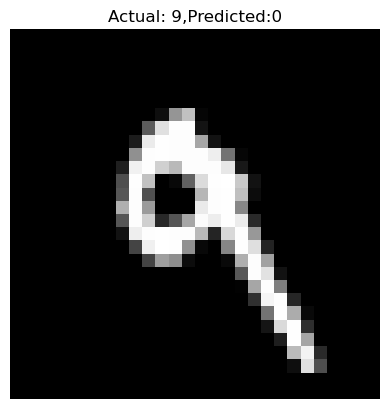

In [21]:
plt.imshow(x_test[7].squeeze(),cmap="gray")
plt.title(f"Actual: {y_test[7]},Predicted:{predicted_label}")
plt.axis("off")
plt.show()